# 🦎 Iguana Species Classification — Transfer Learning Assignment

In this notebook we will classify **7 species of iguana** using Transfer Learning.

The 7 classes are:
- Black_spiny_tailed_iguana
- Brown_anole
- Cuban_knight_anole
- Desert_iguana
- Green_anole
- Green_iguana
- Lesser_Antillean_iguana

**Strategy:** We use a pretrained EfficientNetV2S model (trained on ImageNet) as a **feature extractor** with frozen weights, and add our own classification head on top.

---
### 📁 Expected folder structure
```
data/
  train/
    Black_spiny_tailed_iguana/  *.jpg
    Brown_anole/                *.jpg
    ...
  test/
    1.jpg, 2.jpg, ...
  train.csv               <- filename + label (for verification)
  test.csv                <- id column only (what we need to predict)
  Classes_nummering.xlsx  <- maps class names to numeric IDs
saved_models/             <- trained model will be saved here
```

## Step 0 — Install dependencies & Imports & GPU check

In [1]:
import tensorflow as tf

print(f"TensorFlow versie: {tf.__version__}")
print(f"Aantal GPU's gevonden: {len(tf.config.list_physical_devices('GPU'))}")

I0000 00:00:1777969818.827225   21729 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777969818.887158   21729 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777969820.870902   21729 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow versie: 2.21.0
Aantal GPU's gevonden: 1


In [2]:
# Install all required packages
# Run this cell once; you can skip it on subsequent runs if packages are already installed
!pip install tensorflow>=2.16 \
             numpy \
             pandas \
             matplotlib \
             scikit-learn \
             openpyxl \
             Pillow

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


print(f"TensorFlow version : {tf.__version__}")
print(f"GPUs available     : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.21.0
GPUs available     : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 1 — Configuration

All the hyper-parameters you might want to tweak are collected here.

In [ ]:
# ── paths ──────────────────────────────────────────────────────────────────────
DATA_DIR         = Path("data")
TRAIN_DIR        = DATA_DIR / "train"
TEST_DIR         = DATA_DIR / "test"
TRAIN_CSV        = DATA_DIR / "train.csv"
TEST_CSV         = DATA_DIR / "test.csv"
CLASSES_XLSX     = DATA_DIR / "Classes_nummering.xlsx"

SAVED_MODELS_DIR = Path("saved_models")
SAVED_MODELS_DIR.mkdir(exist_ok=True)   # create the folder if it doesn't exist yet
MODEL_PATH       = SAVED_MODELS_DIR / "iguana_model.keras"
SUBMISSION_PATH  = "submission.csv"

# ── image & training settings ──────────────────────────────────────────────────
IMG_SIZE         = 300       # EfficientNetV2S expects >= 224
BATCH_SIZE       = 32
EPOCHS           = 25
LEARNING_RATE    = 1e-3
VALIDATION_SPLIT = 0.2
SEED             = 42

NUM_CLASSES      = 7

## Step 2 — Explore the data

In [4]:
# ── Read the class numbering ────────────────────────────────────────────────────
classes_df = pd.read_excel(CLASSES_XLSX)
print(classes_df)
print("\nColumns:", classes_df.columns.tolist())

   Class                 Unnamed: 1
0      0  Black_spiny_tailed_iguana
1      1                Brown_anole
2      2         Cuban_knight_anole
3      3              Desert_iguana
4      4                Green_anole
5      5               Green_iguana
6      6    Lesser_Antillean_iguana

Columns: ['Class', 'Unnamed: 1']


In [5]:
# ── Peek at the CSVs ────────────────────────────────────────────────────────────
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

print("train.csv shape:", train_df.shape)
print(train_df.head())
print("\ntest.csv shape:", test_df.shape)
print(test_df.head())

train.csv shape: (1334, 2)
                                                  id  label
0  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
1  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
2  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
3  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
4  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0

test.csv shape: (326, 1)
   id
0   1
1   2
2   3
3   4
4   5


In [6]:
# ── Count images per class ──────────────────────────────────────────────────────
class_counts = {}
for class_dir in sorted(TRAIN_DIR.iterdir()):
    if class_dir.is_dir():
        count = len(list(class_dir.glob("*.jpg")) + list(class_dir.glob("*.jpeg")) + list(class_dir.glob("*.png")))
        class_counts[class_dir.name] = count

print("Images per class:")
for cls, cnt in class_counts.items():
    print(f"  {cls:<40} {cnt}")
print(f"\nTotal training images: {sum(class_counts.values())}")

Images per class:
  Black_spiny_tailed_iguana                199
  Brown_anole                              193
  Cuban_knight_anole                       189
  Desert_iguana                            183
  Green_anole                              178
  Green_iguana                             196
  Lesser_Antillean_iguana                  196

Total training images: 1334


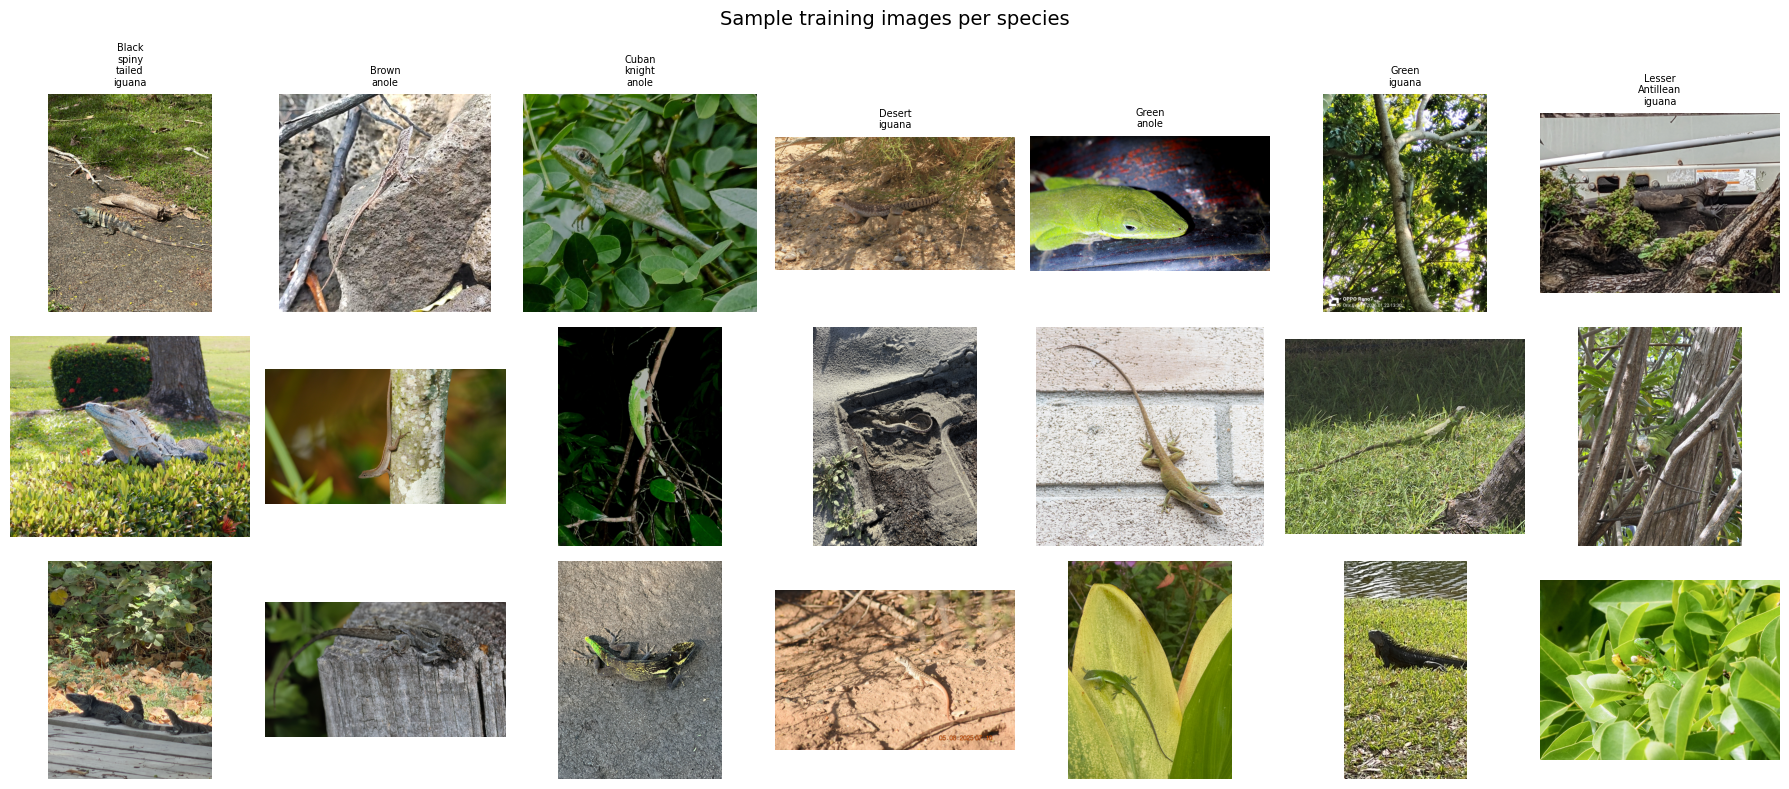

In [7]:
# ── Visualize a few training images ────────────────────────────────────────────
fig, axes = plt.subplots(3, 7, figsize=(18, 8))
class_names = sorted(class_counts.keys())

for col, cls in enumerate(class_names):
    images = list((TRAIN_DIR / cls).glob("*.jpg"))[:3]
    for row, img_path in enumerate(images):
        img = plt.imread(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(cls.replace("_", "\n"), fontsize=7)

plt.suptitle("Sample training images per species", fontsize=14)
plt.tight_layout()
plt.show()

## Step 3 — Build the data pipeline

We use `image_dataset_from_directory` which automatically infers class labels from the subfolder names. **No manual one-hot encoding needed!**

We also apply **data augmentation** to reduce overfitting.

In [8]:
# ── Training & validation datasets ─────────────────────────────────────────────
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",   # one-hot encoded -> use categorical_crossentropy
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode="categorical",
)

# The class names as discovered by Keras (alphabetical order)
CLASS_NAMES = train_ds.class_names
print("Class names (in model order):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

Found 1334 files belonging to 7 classes.
Using 1068 files for training.


I0000 00:00:1777970073.276736   21729 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 1334 files belonging to 7 classes.
Using 266 files for validation.
Class names (in model order):
  0: Black_spiny_tailed_iguana
  1: Brown_anole
  2: Cuban_knight_anole
  3: Desert_iguana
  4: Green_anole
  5: Green_iguana
  6: Lesser_Antillean_iguana


In [9]:
# ── Data augmentation (applied only during training) ───────────────────────────
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

def prepare_train(images, labels):
    images = data_augmentation(images, training=True)
    return images, labels

def prepare_val(images, labels):
    return images, labels

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.map(prepare_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val_ds   = val_ds.map(prepare_val,   num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Pipeline ready")

Pipeline ready


## Step 4 — Build the model

**Architecture:**
1. **Base model** — EfficientNetV2S pretrained on ImageNet, weights **frozen**
2. **Global Average Pooling** — collapses the feature maps into a single vector
3. **Our classification head** — Dense layers leading to a 7-class softmax output

> You can swap `EfficientNetV2S` for another backbone like `ResNet50V2` or `MobileNetV3Large` in one line.

In [10]:
# ── Frozen base model (feature extractor) ──────────────────────────────────────
base_model = EfficientNetV2S(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,     # remove the original ImageNet classification head
    weights="imagenet",    # use pretrained ImageNet weights
)
base_model.trainable = False   # freeze all base layers

# ── Our classification head ────────────────────────────────────────────────────
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(256, activation="relu"),
    Dropout(0.4),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax"),   # softmax for multi-class
], name="iguana_classifier")

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "iguana_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-s (Functional)   │ (None, 12, 12, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,698,215 (78.96 MB)

 Trainable params: 364,295 (1.39 MB)

 Non-trainable params: 20,333,920 (77.57 MB)

## Step 5 — Train the model

In [11]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    # 1. EarlyStopping staat UIT! We gaan helemaal tot het bittere eind.
    # EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    
    # 2. We laten hem wel nog steeds z'n stapgrootte verkleinen als hij vastloopt.
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    
    # 3. DE SAFETY NET: Hij slaat nu na elke ronde automatisch het model op, 
    # MAAR alleen als de val_loss lager (beter) was dan de vorige keer!
    ModelCheckpoint(filepath=MODEL_PATH, monitor='val_loss', save_best_only=True, verbose=1)
]

print(f"Training with frozen base for ALL {EPOCHS} epochs (No Early Stopping!)...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

# Omdat de ModelCheckpoint het opslaan al regelt, heb je deze regel eigenlijk niet meer nodig, 
# maar hij is handig als backup (al slaat hij dan dus de overfitte versie over je goeie heen!)
model.save(MODEL_PATH) 

print(f"\nTraining klaar! Check je grafieken maar eens.")

Training with frozen base for ALL 50 epochs (No Early Stopping!)...
Epoch 1/50


W0000 00:00:1777970094.286896   22813 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 56624128 bytes after encountering the first element of size 56624128 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
I0000 00:00:1777970094.351783   22629 service.cc:153] XLA service 0x7f7f540bf5f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777970094.351809   22629 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777970095.626874   22629 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777970100.017891   22629 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777970101.569062   22629 dot_merger.cc:481] Merging Dots in compu

33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.3417 - loss: 1.9766

I0000 00:00:1777970149.418188   22626 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_35439__.500
E0000 00:00:1777970153.041502   22626 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777970156.373574   22626 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777970158.721024   22626 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3445 - loss: 1.9676   

...


Epoch 49: val_loss did not improve from 0.71001
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.8642 - loss: 0.3836 - val_accuracy: 0.7632 - val_loss: 0.7308 - learning_rate: 3.8147e-09
Epoch 50/50
 1/34 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6875 - loss: 0.6911

W0000 00:00:1777970602.443741   22813 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 56624128 bytes after encountering the first element of size 56624128 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


33/34 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.8389 - loss: 0.4078

W0000 00:00:1777970607.196529   25473 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67109888 bytes after encountering the first element of size 67109888 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size



Epoch 50: ReduceLROnPlateau reducing learning rate to 1.907348723406699e-09.

Epoch 50: val_loss did not improve from 0.71001
34/34 ━━━━━━━━━━━━━━━━━━━━ 7s 172ms/step - accuracy: 0.8567 - loss: 0.3885 - val_accuracy: 0.7556 - val_loss: 0.7323 - learning_rate: 3.8147e-09

Training klaar! Check je grafieken maar eens.


In [12]:
# # ── Stap 1: Ontdooi het beest ──────────────────────────────────────────────────
# # (Vervang 'base_model' door de naam die het in jouw script heeft, 
# # waarschijnlijk iets als 'base_model' of 'efficientnet')
# base_model.trainable = True

# print("Basismodel is ontdooid! Aantal trainbare parameters is zojuist geëxplodeerd.")

# # ── Stap 2: Het model OPNIEUW compileren (CRUCIAAL) ────────────────────────────
# # Zodra je .trainable aanpast, MOET je het model opnieuw compileren, 
# # anders pakt Keras de ontdooiing niet op.

# FINETUNE_LR = 1e-5  # Dit is 0.00001 (100 keer trager dan je eerste run!)

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
#     loss='sparse_categorical_crossentropy', # of 'categorical_crossentropy' (check wat je in je eerste compile had!)
#     metrics=['accuracy']
# )

# # ── Stap 3: De tweede trainingsronde ───────────────────────────────────────────
# # We kunnen gewoon dezelfde EarlyStopping en ReduceLROnPlateau callbacks hergebruiken!
# FINETUNE_EPOCHS = 30

# print(f"Start Fine-Tuning voor maximaal {FINETUNE_EPOCHS} epochs...")

# # Convert one-hot labels to integer labels to match 'sparse_categorical_crossentropy'
# train_ds_sparse = train_ds.map(
#     lambda x, y: (x, tf.cast(tf.argmax(y, axis=1), tf.int32)),
#     num_parallel_calls=AUTOTUNE
# ).prefetch(AUTOTUNE)

# val_ds_sparse = val_ds.map(
#     lambda x, y: (x, tf.cast(tf.argmax(y, axis=1), tf.int32)),
#     num_parallel_calls=AUTOTUNE
# ).prefetch(AUTOTUNE)

# history_finetune = model.fit(
#     train_ds_sparse,
#     validation_data=val_ds_sparse,
#     epochs=FINETUNE_EPOCHS,
#     callbacks=callbacks
# )

# # Sla dit nieuwe, oppermachtige model op onder een nieuwe naam
# FINETUNED_MODEL_PATH = SAVED_MODELS_DIR / "iguana_model_finetuned.keras"
# model.save(FINETUNED_MODEL_PATH)
# print(f"\nFine-tuned model bewaard in: {FINETUNED_MODEL_PATH}")

## Step 6 — Visualize training

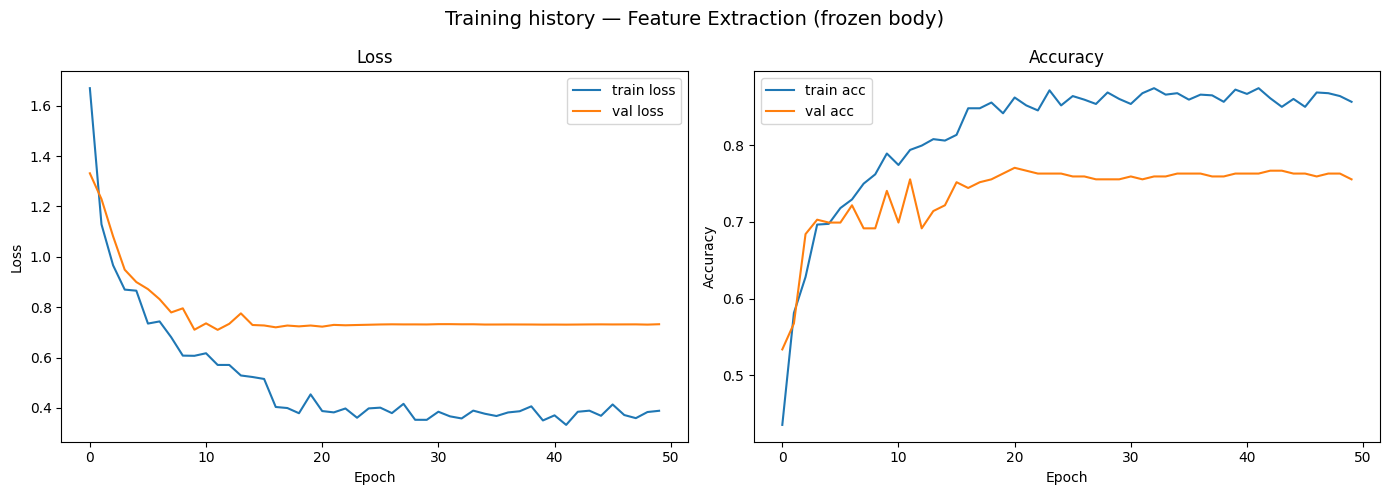

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history["loss"],     label="train loss")
ax1.plot(history.history["val_loss"], label="val loss")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(history.history["accuracy"],     label="train acc")
ax2.plot(history.history["val_accuracy"], label="val acc")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.legend()

plt.suptitle("Training history — Feature Extraction (frozen body)", fontsize=14)
plt.tight_layout()
plt.show()

## Step 7 — Evaluate on validation set

In [14]:
val_loss, val_acc = model.evaluate(val_ds, verbose=1)
print(f"\nValidation accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
print(f"\nValidation accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

W0000 00:00:1777970610.122000   25473 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67109888 bytes after encountering the first element of size 67109888 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.7556 - loss: 0.7323

Validation accuracy: 0.7556 (75.56%)

Validation accuracy: 0.7556 (75.56%)


W0000 00:00:1777970612.375148   21729 prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 67109888 bytes after encountering the first element of size 67109888 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


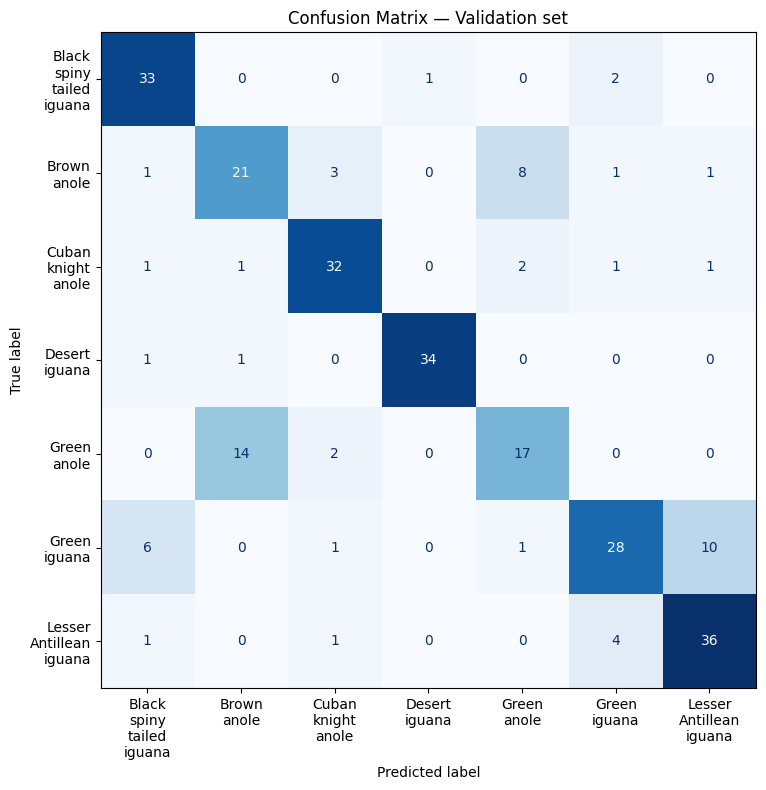

In [15]:
# ── Confusion matrix ────────────────────────────────────────────────────────────
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=[c.replace("_", "\n") for c in CLASS_NAMES])
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
plt.title("Confusion Matrix — Validation set")
plt.tight_layout()
plt.show()

## Step 8 — Generate submission file

Read the test images, predict, map class indices back to the numeric IDs from `Classes_nummering.xlsx`, and write `submission.csv`.

In [16]:
# ── Load class numbering from xlsx ─────────────────────────────────────────────
# Inspect the columns printed in Step 2 and adjust the indices here if needed
classes_df = pd.read_excel(CLASSES_XLSX)

NAME_COL = classes_df.columns[0]   # column with the species name string
ID_COL   = classes_df.columns[1]   # column with the numeric id

name_to_id = dict(zip(classes_df[NAME_COL], classes_df[ID_COL]))
print("name -> id mapping:", name_to_id)

name -> id mapping: {0: 'Black_spiny_tailed_iguana', 1: 'Brown_anole', 2: 'Cuban_knight_anole', 3: 'Desert_iguana', 4: 'Green_anole', 5: 'Green_iguana', 6: 'Lesser_Antillean_iguana'}


In [17]:
# ── Read test ids ───────────────────────────────────────────────────────────────
test_df   = pd.read_csv(TEST_CSV)
ID_COLUMN = test_df.columns[0]   # usually 'id' or 'ID'
test_ids  = test_df[ID_COLUMN].tolist()
print(f"{len(test_ids)} test images to predict")

326 test images to predict


In [18]:
# ── Predict on test images ──────────────────────────────────────────────────────
predictions = []

for img_id in test_ids:
    for ext in [".jpg", ".jpeg", ".png"]:
        img_path = TEST_DIR / f"{img_id}{ext}"
        if img_path.exists():
            break

    img       = tf.keras.utils.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.expand_dims(tf.keras.utils.img_to_array(img), axis=0)

    pred       = model.predict(img_array, verbose=0)
    class_name = CLASS_NAMES[np.argmax(pred[0])]
    predictions.append(classes_df.loc[classes_df[ID_COL] == class_name, NAME_COL].iloc[0])

print(f"Done! {len(predictions)} predictions made.")
print("Sample:", predictions[:10])

E0000 00:00:1777970637.153008   22625 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777970637.887260   22625 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1777970638.594632   22625 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Done! 326 predictions made.
Sample: [np.int64(6), np.int64(5), np.int64(4), np.int64(5), np.int64(0), np.int64(4), np.int64(6), np.int64(4), np.int64(5), np.int64(1)]


In [19]:
# ── Write submission.csv ────────────────────────────────────────────────────────
submission_df = pd.DataFrame({ID_COLUMN: test_ids, "label": predictions})
submission_df.to_csv(SUBMISSION_PATH, index=False)
print(f"Submission saved to: {SUBMISSION_PATH}")
print(submission_df.head(10))

Submission saved to: submission.csv
   id  label
0   1      6
1   2      5
2   3      4
3   4      5
4   5      0
5   6      4
6   7      6
7   8      4
8   9      5
9  10      1


---
## Things to experiment with

Once the baseline is working, here are knobs you can turn to improve accuracy:

| What | Where | Try |
|------|-------|-----|
| **Base model** | Step 4 | Swap `EfficientNetV2S` -> `ResNet50V2`, `MobileNetV3Large`, `ConvNeXtBase` |
| **Image size** | Step 1 config | 224 -> 300 or 384 (bigger = more detail, more memory) |
| **Augmentation** | Step 3 | Add `RandomFlip("vertical")`, `RandomTranslation`, `RandomShear` |
| **Head architecture** | Step 4 | More/fewer Dense layers, different Dropout rates |
| **Epochs** | Step 1 config | Increase `EPOCHS` |
| **Fine-tuning** | After Step 5 | Set `base_model.trainable = True`, recompile with `lr=1e-5`, train again |
| **Class weights** | `model.fit()` | Add `class_weight=...` if classes are imbalanced |
| **Batch size** | Step 1 config | Smaller = noisier gradients (sometimes helps generalization) |